# Facial recognition with medical mask
#### Kosharova, Oliinyk 50-50

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import re
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

np.random.seed(42)
tf.random.set_seed(42)

In [2]:
DATASET_PATH = './data/Dataset/Dataset'
IMG_SIZE = 224
EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-5

## EDA

In [3]:
all_files = [f for f in os.listdir(DATASET_PATH) if f.endswith('.jpg')]

with_mask_files = [f for f in all_files if '-with-mask' in f]
without_mask_files = [f for f in all_files if '-with-mask' not in f]

print(f"Total number of images: {len(all_files)}")
print(f"Images with mask: {len(with_mask_files)}")
print(f"Images without mask: {len(without_mask_files)}")

Total number of images: 1965
Images with mask: 965
Images without mask: 1000


In [4]:
data = []
for file in all_files:
    label = 1 if '-with-mask' in file else 0
    label_name = 'with_mask' if label == 1 else 'without_mask'
    data.append({
        'filename': file,
        'label': label,
        'label_name': label_name,
        'filepath': os.path.join(DATASET_PATH, file)
    })

df = pd.DataFrame(data)
print("\nDataset DataFrame:")
print(df.head(10))


Dataset DataFrame:
                  filename  label    label_name  \
0  img000001-with-mask.jpg      1     with_mask   
1            img000001.jpg      0  without_mask   
2  img000002-with-mask.jpg      1     with_mask   
3            img000002.jpg      0  without_mask   
4            img000003.jpg      0  without_mask   
5            img000004.jpg      0  without_mask   
6  img000005-with-mask.jpg      1     with_mask   
7            img000005.jpg      0  without_mask   
8  img000006-with-mask.jpg      1     with_mask   
9            img000006.jpg      0  without_mask   

                                         filepath  
0  ./data/Dataset/Dataset\img000001-with-mask.jpg  
1            ./data/Dataset/Dataset\img000001.jpg  
2  ./data/Dataset/Dataset\img000002-with-mask.jpg  
3            ./data/Dataset/Dataset\img000002.jpg  
4            ./data/Dataset/Dataset\img000003.jpg  
5            ./data/Dataset/Dataset\img000004.jpg  
6  ./data/Dataset/Dataset\img000005-with-mask.jpg  
7 

In [5]:
class_counts = df['label_name'].value_counts()
class_percentages = df['label_name'].value_counts(normalize=True) * 100

print("Class Distribution:")
for label, count in class_counts.items():
    percentage = class_percentages[label]
    print(f"{label}: {count} images ({percentage:.2f}%)")

Class Distribution:
without_mask: 1000 images (50.89%)
with_mask: 965 images (49.11%)


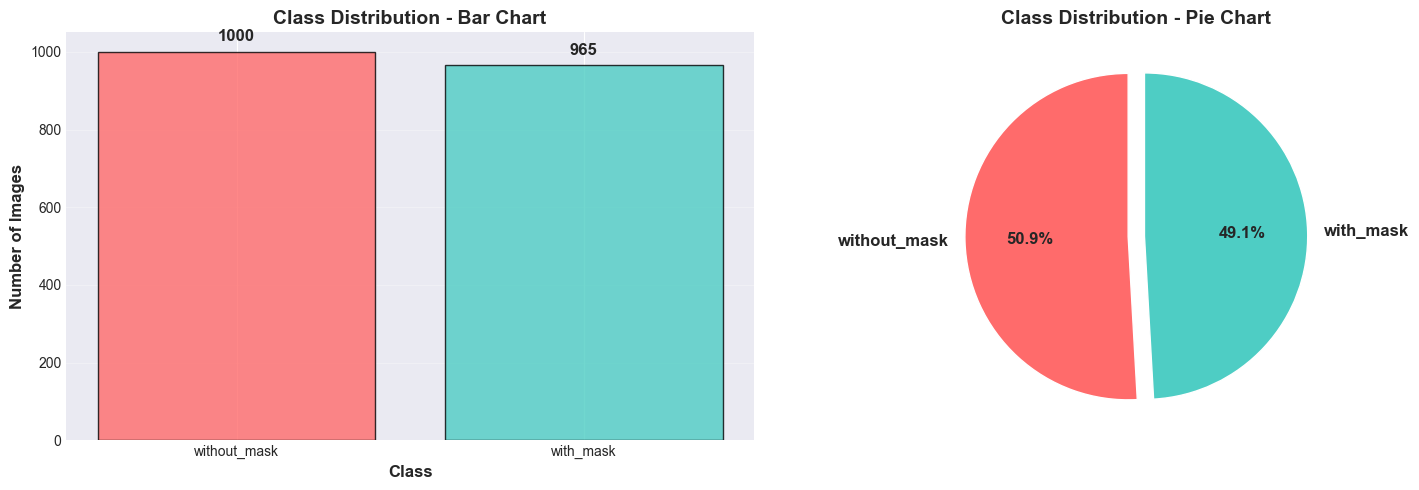

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#FF6B6B', '#4ECDC4']
axes[0].bar(class_counts.index, class_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Images', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution - Bar Chart', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for i, (label, count) in enumerate(class_counts.items()):
    axes[0].text(i, count + 20, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05),
            textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution - Pie Chart', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
image_info = []
for idx, row in df.iterrows():
    try:
        img = Image.open(row['filepath'])
        width, height = img.size
        aspect_ratio = width / height

        image_info.append({
            'filename': row['filename'],
            'label': row['label_name'],
            'width': width,
            'height': height,
            'aspect_ratio': aspect_ratio,
        })
    except Exception as e:
        print(f"Error processing {row['filename']}: {e}")

df_info = pd.DataFrame(image_info)

print("\nImage Properties Statistics:")
print(df_info.describe())


Image Properties Statistics:
        width  height  aspect_ratio
count  1965.0  1965.0   1965.000000
mean    178.0   218.0      0.816514
std       0.0     0.0      0.000000
min     178.0   218.0      0.816514
25%     178.0   218.0      0.816514
50%     178.0   218.0      0.816514
75%     178.0   218.0      0.816514
max     178.0   218.0      0.816514


In [8]:
unique_dimensions = df_info.groupby(['width', 'height']).size().reset_index(name='count')
print(f"\nNumber of unique image dimensions: {len(unique_dimensions)}")
print("\nMost common dimensions:")
print(unique_dimensions.nlargest(5, 'count'))


Number of unique image dimensions: 1

Most common dimensions:
   width  height  count
0    178     218   1965


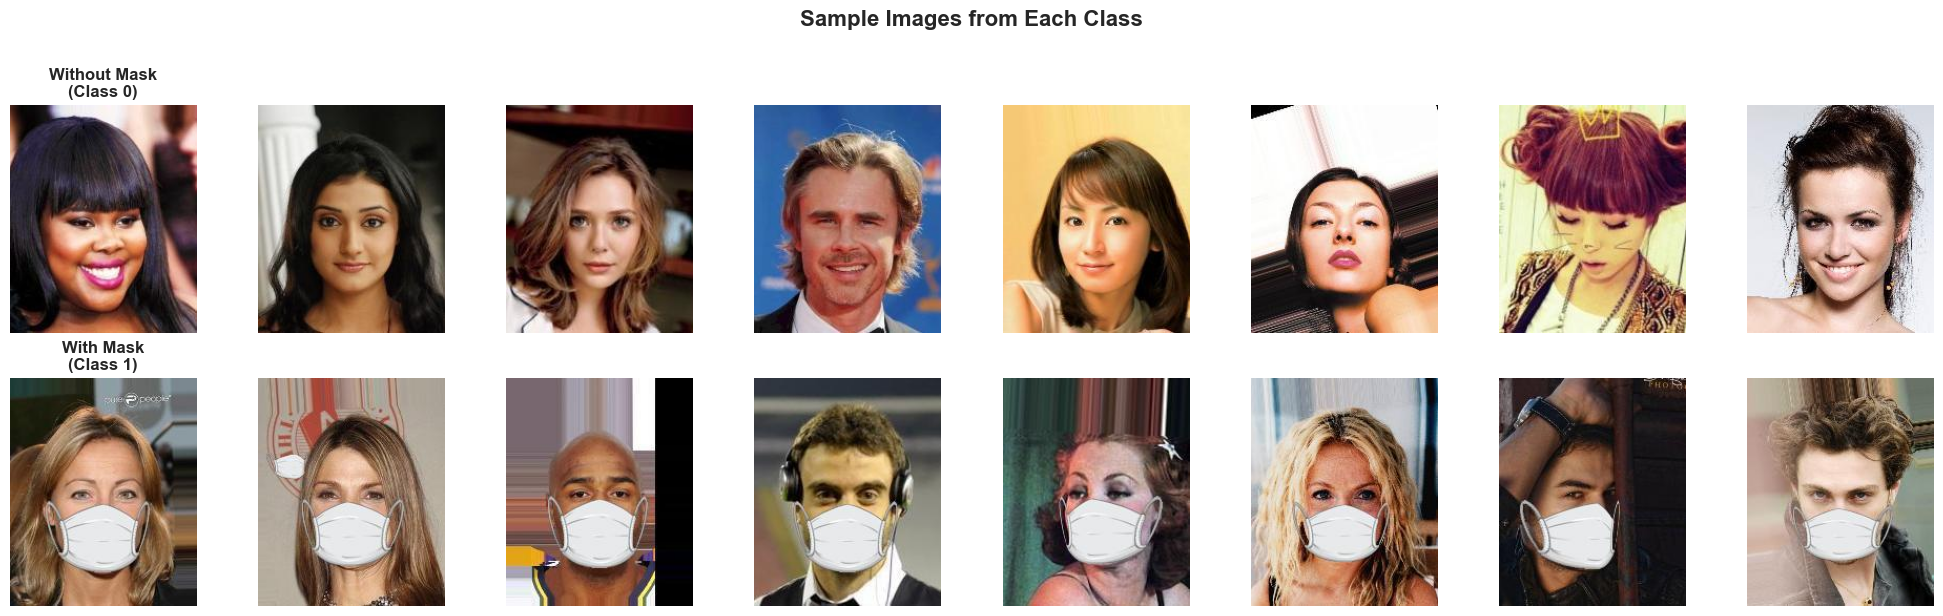

In [9]:
def display_samples(df, n_samples=8):
    fig, axes = plt.subplots(2, n_samples, figsize=(20, 6))

    without_mask_samples = df[df['label'] == 0].sample(n=n_samples, random_state=42)
    for idx, (_, row) in enumerate(without_mask_samples.iterrows()):
        img = Image.open(row['filepath'])
        axes[0, idx].imshow(img)
        axes[0, idx].axis('off')
        if idx == 0:
            axes[0, idx].set_title('Without Mask\n(Class 0)', fontsize=12, fontweight='bold')
        else:
            axes[0, idx].set_title('')

    with_mask_samples = df[df['label'] == 1].sample(n=n_samples, random_state=42)
    for idx, (_, row) in enumerate(with_mask_samples.iterrows()):
        img = Image.open(row['filepath'])
        axes[1, idx].imshow(img)
        axes[1, idx].axis('off')
        if idx == 0:
            axes[1, idx].set_title('With Mask\n(Class 1)', fontsize=12, fontweight='bold')
        else:
            axes[1, idx].set_title('')

    plt.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

display_samples(df, n_samples=8)

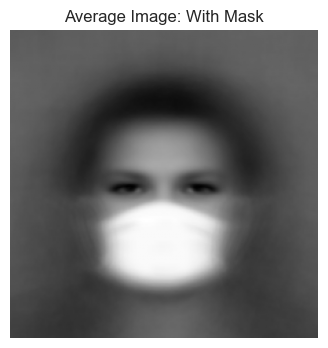

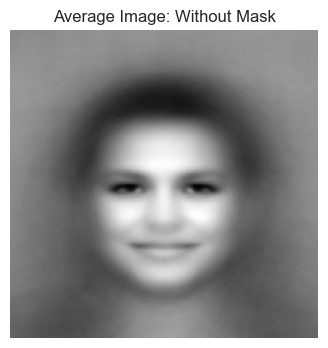

In [10]:
def mean_image_from_paths(image_paths, title, img_size=(IMG_SIZE, IMG_SIZE)):
    images = []

    for path in image_paths:
        img = Image.open(path).convert("L")
        img = img.resize(img_size)
        images.append(np.array(img))

    images = np.stack(images, axis=0)

    mean_img = np.mean(images, axis=0)

    plt.figure(figsize=(4, 4))
    plt.imshow(mean_img, cmap='gray')
    plt.title(f'Average Image: {title}')
    plt.axis('off')
    plt.show()

    return mean_img


with_mask_mean = mean_image_from_paths(
    df[df['label'] == 1]['filepath'],
    title='With Mask'
)

without_mask_mean = mean_image_from_paths(
    df[df['label'] == 0]['filepath'],
    title='Without Mask'
)


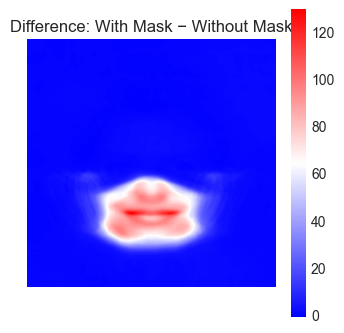

In [11]:
diff_mean = with_mask_mean - without_mask_mean

plt.figure(figsize=(4, 4))
plt.imshow(diff_mean, cmap='bwr')
plt.colorbar()
plt.title('Difference: With Mask − Without Mask')
plt.axis('off')
plt.show()


Dataset obsahuje 1965 obrázkov a triedy with mask a without mask sú takmer vyvážené

Štruktúra daťasetu je taká, že väčšina ľudí má dve fotky, s maskou a bez masky

Analýza vlastností obrázkov potvrdila, že všetky snímky majú rovnaké rozmery a pomer strán, čo zjednodušuje proces predspracovania dát

Hlavné rozdiely medzi triedami sa nachádzajú v oblasti dolnej časti tváre, kde je v triede with mask prítomná maska a v triede without mask sú viditeľné črty úst a brady


## Data preprocessing

In [12]:
def extract_person_id(filename):
    match = re.match(r'img(\d+)', filename)
    if match:
        return match.group(1)
    return None

df['person_id'] = df['filename'].apply(extract_person_id)

print(f"\nExamples person_id:")
print(df[['filename', 'person_id', 'label']].head(10))

print(f"\nToral num of images: {len(df)}")
print(f"Num of unique person: {df['person_id'].nunique()}")

unique_persons = df['person_id'].unique()

person_labels = df.groupby('person_id')['label'].first()



Examples person_id:
                  filename person_id  label
0  img000001-with-mask.jpg    000001      1
1            img000001.jpg    000001      0
2  img000002-with-mask.jpg    000002      1
3            img000002.jpg    000002      0
4            img000003.jpg    000003      0
5            img000004.jpg    000004      0
6  img000005-with-mask.jpg    000005      1
7            img000005.jpg    000005      0
8  img000006-with-mask.jpg    000006      1
9            img000006.jpg    000006      0

Toral num of images: 1965
Num of unique person: 1000


In [13]:
df_filtered = df.groupby('person_id').sample(n=1, random_state=42)

train_df, temp1 = train_test_split(df_filtered, test_size=0.4, stratify=df_filtered['label'], random_state=42)
val_df, test_df = train_test_split(temp1, test_size=0.5, stratify=temp1['label'], random_state=42)

In [14]:
def load_image(filepath, img_size=IMG_SIZE):
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype("float32")
    return img

X_train = np.array([load_image(fp) for fp in train_df['filepath']])
y_train = train_df['label'].values

X_val = np.array([load_image(fp) for fp in val_df['filepath']])
y_val = val_df['label'].values

X_test = np.array([load_image(fp) for fp in test_df['filepath']])
y_test = test_df['label'].values

print(f"\nData shapes:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")


Data shapes:
X_train: (600, 224, 224, 3), y_train: (600,)
X_val: (200, 224, 224, 3), y_val: (200,)
X_test: (200, 224, 224, 3), y_test: (200,)


In [15]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
    layers.RandomTranslation(0.2, 0.2),
    layers.RandomBrightness(0.3),
    layers.RandomCrop(int(IMG_SIZE * 0.9), int(IMG_SIZE * 0.9)),
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.GaussianNoise(0.5),

], name="data_augmentation")

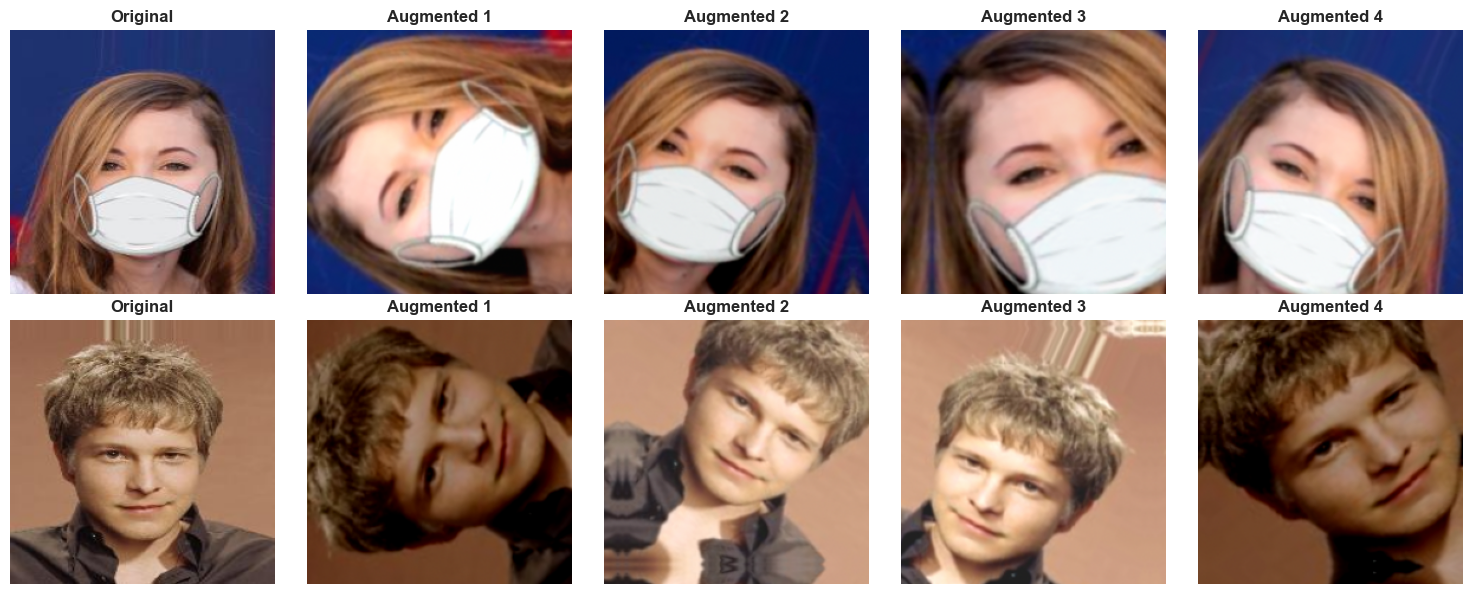

In [32]:
def fix_for_plot(img):
    img = img.astype("float32")

    if img.max() <= 1.0:
        img = img * 255.0

    img = np.clip(img, 0, 255).astype("uint8")
    return img


sample_image = X_train[0:1]
sample_image2 = X_train[1:2]

fig, axes = plt.subplots(2, 5, figsize=(15, 6))


axes[0, 0].imshow(fix_for_plot(sample_image[0]))
axes[0, 0].set_title("Original", fontweight="bold")
axes[0, 0].axis("off")

for i in range(1, 5):
    augmented = data_augmentation(sample_image, training=True)
    aug_img = fix_for_plot(augmented[0].numpy())
    axes[0, i].imshow(aug_img)
    axes[0, i].set_title(f"Augmented {i}", fontweight="bold")
    axes[0, i].axis("off")


axes[1, 0].imshow(fix_for_plot(sample_image2[0]))
axes[1, 0].set_title("Original", fontweight="bold")
axes[1, 0].axis("off")

for i in range(1, 5):
    augmented = data_augmentation(sample_image2, training=True)
    aug_img = fix_for_plot(augmented[0].numpy())
    axes[1, i].imshow(aug_img)
    axes[1, i].set_title(f"Augmented {i}", fontweight="bold")
    axes[1, i].axis("off")


plt.tight_layout()
plt.show()

Z dôvodu, že väčšina jednotlivcov má v datasete dva obrázky – s maskou a bez masky, bolo pred rozdelením dát zabezpečené, aby sa obrázky tej istej osoby nevyskytovali vo viacerých dátových množinách, čím sa zabránilo úniku informácií medzi trénovacou, validačnou a testovacou množinou

Dáta boli následne rozdelené na trénovaciu, validačnú a testovaciu množinu v pomere 60 : 20 : 20

Všetky obrázky boli prevedené do jednotného formátu, zmenené na rovnaké rozmery a transformované na numerické vstupy vhodné pre hlboké neurónové siete

Na zvýšenie variability dát a zlepšenie generalizačnej schopnosti modelov bola použitá dátová augmentácia zahŕňajúca geometrické a fotometrické transformácie, ako sú rotácia, zmena mierky, posun, zmena jasu, kontrastu a pridanie šumu


## Výber ML/DL metód

Vzhľadom na obrazový charakter dát boli pre riešenie úlohy zvolené konvolučné neurónové siete CNN, ktoré dokážu automaticky extrahovať relevantné vizuálne príznaky z obrazov a sú štandardným prístupom pre úlohy obrazovej klasifikácie

Vlastná CNN architektúra bola navrhnutá ako jednoduchý základný model s cieľom overiť schopnosť CNN riešiť danú úlohu pri minimálnej architektonickej zložitosti. Tento model slúži ako referenčný bod a umožňuje rýchly tréning a základné porovnanie s pokročilejšími architektúrami.

LeNet-5 bol zvolený ako klasická a dobre známa CNN architektúra, ktorá predstavuje historický základ konvolučných neurónových sietí. Vďaka svojej jednoduchej štruktúre a malému počtu parametrov umožňuje stabilný tréning

MobileNetV2 bol vybraný ako moderná a výpočtovo efektívna architektúra optimalizovaná pre praktické nasadenie. Využíva hĺbkovo separovateľné konvolúcie a inverzné reziduálne bloky, čo výrazne znižuje počet parametrov a výpočtov pri zachovaní dobrej klasifikačnej presnosti. Použitie predtrénovaných váh zároveň umožňuje efektívne využiť transfer learning pri relatívne malom datasete

Tieto tri modely sa líšia najmä architektonickou zložitosťou, počtom parametrov a výpočtovou náročnosťou. Ich porovnanie umožňuje analyzovať vplyv komplexnosti modelu na presnosť a generalizačnú schopnosť pri danej klasifikačnej úlohe

## Modeling

In [17]:
def create_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(16, 3, activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),

        layers.Conv2D(32, 3, activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


custom_cnn = create_custom_cnn()
print("Custom CNN Model Summary")
custom_cnn.summary()

Custom CNN Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (1, 222, 222, 16)      │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (1, 111, 111, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (1, 109, 109, 32)      │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (1, 54, 54, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (1, 93312)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (1, 32)                │     2,986,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 32)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (1, 1)                 │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,991,137 (11.41 MB)

 Trainable params: 2,991,137 (11.41 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
def create_lenet5(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    model = models.Sequential([
        data_augmentation,
        layers.Rescaling(1./255),

        layers.Conv2D(
            6, kernel_size=5, activation='relu',
            padding='same', input_shape=input_shape
        ),
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        layers.Conv2D(16, kernel_size=5, activation='relu'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)),

        layers.Flatten(),
        layers.Dense(120, activation='relu'),
        layers.Dense(84, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


lenet5 = create_lenet5()
print("LeNet-5 Model Summary")
lenet5.summary()

LeNet-5 Model Summary


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (1, 224, 224, 6)       │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (1, 112, 112, 6)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (1, 108, 108, 16)      │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (1, 54, 54, 16)        │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (1, 46656)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (1, 120)               │     5,598,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (1, 84)                │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (1, 1)                 │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,611,961 (21.41 MB)

 Trainable params: 5,611,961 (21.41 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
def create_mobilenetv2(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = True

    model = models.Sequential([
        data_augmentation,
        layers.Rescaling(1./255),

        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    return model


mobilenetv2 = create_mobilenetv2()
print("MobileNetV2 Model Summary")
mobilenetv2.summary()

MobileNetV2 Model Summary


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (1, 224, 224, 3)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (1, 7, 7, 1280)        │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (1, 1280)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (1, 64)                │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (1, 1)                 │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 2,305,921 (8.80 MB)

 Non-trainable params: 34,112 (133.25 KB)

## Training

In [20]:
metrics = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

In [21]:
print("Training Custom CNN:")

custom_cnn.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=metrics
)

history_custom = custom_cnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training Custom CNN:
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 127ms/step - accuracy: 0.5917 - loss: 0.6845 - precision: 0.5767 - recall: 0.5945 - val_accuracy: 0.6650 - val_loss: 0.6675 - val_precision: 0.6364 - val_recall: 0.7216
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.6133 - loss: 0.6681 - precision: 0.6234 - recall: 0.5120 - val_accuracy: 0.6700 - val_loss: 0.6463 - val_precision: 0.6281 - val_recall: 0.7835
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - accuracy: 0.6833 - loss: 0.6408 - precision: 0.6747 - recall: 0.6701 - val_accuracy: 0.7100 - val_loss: 0.6229 - val_precision: 0.7468 - val_recall: 0.6082
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.6683 - loss: 0.6303 - precision: 0.6620 - recall: 0.6460 - val_accuracy: 0.7150 - val_loss: 0.6034 - val_precision: 0.8030 - val_recall: 0.5464
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.6817 - loss: 0.6195 - precision: 0.7174 - recall: 0.5670 - val_accuracy: 

In [22]:
print("Training LeNet-5:")

lenet5.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=metrics
)

history_lenet5 = lenet5.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training LeNet-5:
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.5883 - loss: 0.6821 - precision: 0.6703 - recall: 0.6340 - val_accuracy: 0.6000 - val_loss: 0.6726 - val_precision: 0.5714 - val_recall: 0.7010
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5883 - loss: 0.6732 - precision: 0.5629 - recall: 0.6770 - val_accuracy: 0.5800 - val_loss: 0.6685 - val_precision: 0.5546 - val_recall: 0.6804
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.6167 - loss: 0.6605 - precision: 0.5874 - recall: 0.7045 - val_accuracy: 0.5950 - val_loss: 0.6564 - val_precision: 0.5667 - val_recall: 0.7010
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.6200 - loss: 0.6519 - precision: 0.5868 - recall: 0.7320 - val_accuracy: 0.5900 - val_loss: 0.6452 - val_precision: 0.5641 - val_recall: 0.6804
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.6450 - loss: 0.6458 - precision: 0.6204 - recall: 0.6907 - val_accuracy: 0.6200 

In [23]:
print("Training MobileNetV2:")

mobilenetv2.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=metrics
)

history_mobilenet = mobilenetv2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Training MobileNetV2:
Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 945ms/step - accuracy: 0.5217 - loss: 0.7491 - precision: 0.5873 - recall: 0.6933 - val_accuracy: 0.3400 - val_loss: 0.8164 - val_precision: 0.3759 - val_recall: 0.5464
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 903ms/step - accuracy: 0.6433 - loss: 0.6427 - precision: 0.6142 - recall: 0.7113 - val_accuracy: 0.5250 - val_loss: 0.7122 - val_precision: 0.5075 - val_recall: 0.7010
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 894ms/step - accuracy: 0.7150 - loss: 0.5484 - precision: 0.6863 - recall: 0.7595 - val_accuracy: 0.6550 - val_loss: 0.6269 - val_precision: 0.6111 - val_recall: 0.7938
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 895ms/step - accuracy: 0.8217 - loss: 0.4407 - precision: 0.7987 - recall: 0.8454 - val_accuracy: 0.7650 - val_loss: 0.5531 - val_precision: 0.7119 - val_recall: 0.8660
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 894ms/step - accuracy: 0.8583 - loss: 0.3900 - precision: 0.8411 - recall: 0.8729 - val_accu

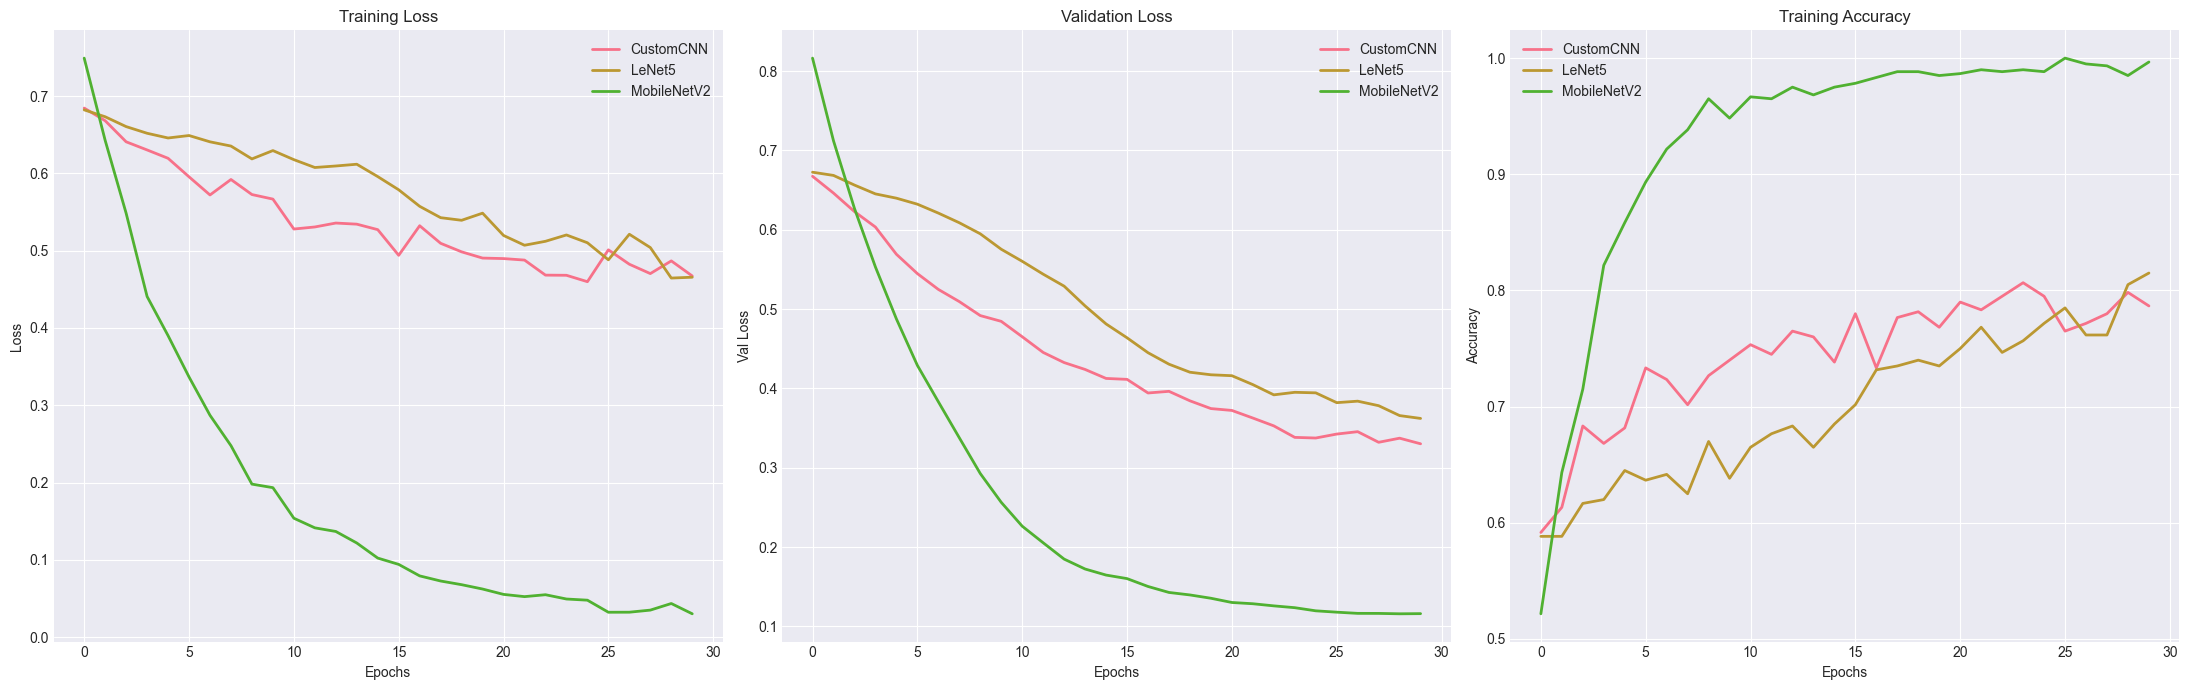

In [24]:
def find_metric_name(history, base_name):
    for key in history.history.keys():
        if key.startswith(base_name):
            return key
    return None


histories = {
    "CustomCNN": history_custom,
    "LeNet5": history_lenet5,
    "MobileNetV2": history_mobilenet
}

precision_keys = {
    name: find_metric_name(hist, "precision")
    for name, hist in histories.items()
}

recall_keys = {
    name: find_metric_name(hist, "recall")
    for name, hist in histories.items()
}

auc_keys = {
    name: find_metric_name(hist, "auc")
    for name, hist in histories.items()
}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
axes = axes.flatten()

ax = axes[0]
for name, hist in histories.items():
    ax.plot(hist.history["loss"], label=name, linewidth=2)
ax.set_title("Training Loss")
ax.set_xlabel("Epochs")
ax.set_ylabel("Loss")
ax.grid(True)
ax.legend()

ax = axes[1]
for name, hist in histories.items():
    ax.plot(hist.history["val_loss"], label=name, linewidth=2)
ax.set_title("Validation Loss")
ax.set_xlabel("Epochs")
ax.set_ylabel("Val Loss")
ax.grid(True)
ax.legend()

ax = axes[2]
for name, hist in histories.items():
    ax.plot(hist.history["accuracy"], label=name, linewidth=2)
ax.set_title("Training Accuracy")
ax.set_xlabel("Epochs")
ax.set_ylabel("Accuracy")
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()


## Evaluation

In [25]:
results = {
    "CustomCNN": {"model": custom_cnn},
    "LeNet5": {"model": lenet5},
    "MobileNetV2": {"model": mobilenetv2}
}

summary = []

for name, entry in results.items():
    model = entry["model"]

    y_proba = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_proba > 0.5).astype(int)

    eval_results = model.evaluate(X_test, y_test, verbose=0)

    loss = eval_results[0]
    acc = eval_results[1]

    prec, rec = None, None

    if len(eval_results) >= 4:
        prec = eval_results[2]
        rec = eval_results[3]

    if prec is not None and rec is not None:
        f1 = 2 * (prec * rec) / (prec + rec + 1e-6)
    else:
        f1 = None

    summary.append([name, acc, prec, rec, f1, loss])

    entry["pred"] = y_pred
    entry["proba"] = y_proba


results_df = pd.DataFrame(
    summary,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "Loss"]
)

results_df


,Model,Accuracy,Precision,Recall,F1-Score,Loss
0,CustomCNN,0.925,0.886792,0.969072,0.926108,0.322872
1,LeNet5,0.910,0.891089,0.927835,0.909090,0.358071
2,MobileNetV2,0.980,0.960396,1.000000,0.979797,0.109976


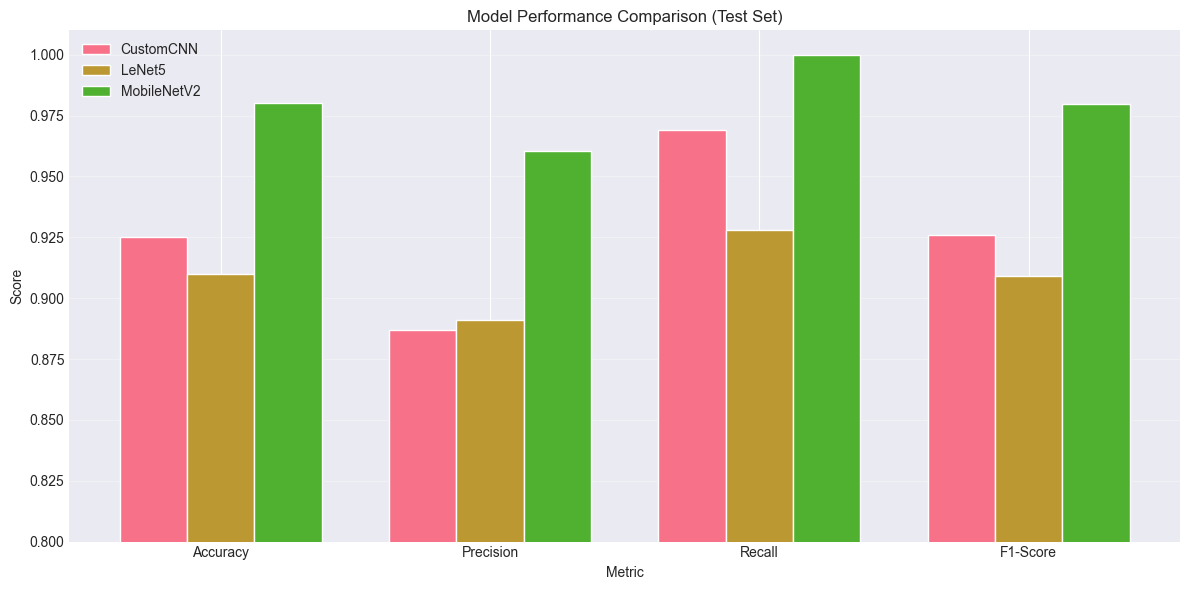

In [26]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
models = results_df["Model"].values

values = results_df[metrics].values

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(12, 6))

for i, model in enumerate(models):
    plt.bar(
        x + i * width,
        values[i],
        width=width,
        label=model
    )

plt.xticks(x + width, metrics)
plt.ylim(0.8, 1.01)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Model Performance Comparison (Test Set)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


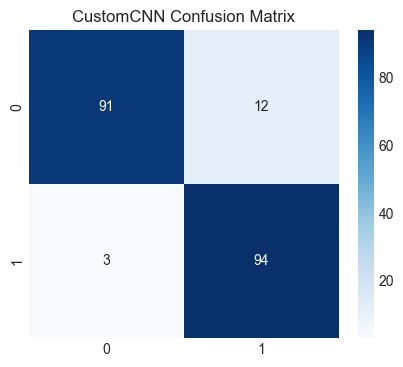

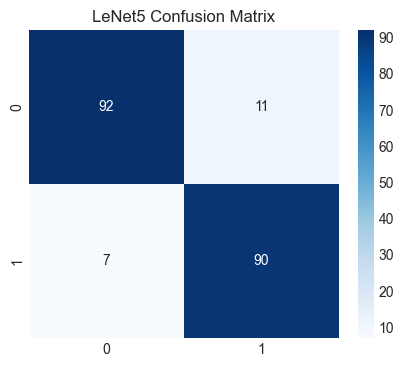

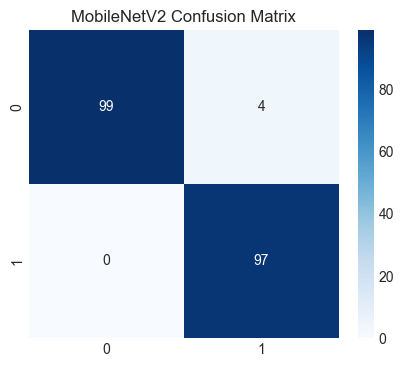

In [27]:
for name, entry in results.items():
    plt.figure(figsize=(5,4))
    cm = confusion_matrix(y_test, entry["pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name + " Confusion Matrix")
    plt.show()

In [28]:
best_row = results_df.loc[results_df["F1-Score"].idxmax()]

print("Best model based on F1-score:")
print(f"Model: {best_row['Model']}")
print(f"\tAccuracy:  {best_row['Accuracy']:.4f}")
print(f"\tPrecision: {best_row['Precision']:.4f}")
print(f"\tRecall:    {best_row['Recall']:.4f}")
print(f"\tF1-score:  {best_row['F1-Score']:.4f}")
print(f"\tLoss:      {best_row['Loss']:.4f}")


Best model based on F1-score:
Model: MobileNetV2
	Accuracy:  0.9800
	Precision: 0.9604
	Recall:    1.0000
	F1-score:  0.9798
	Loss:      0.1100



Best epoch: 29
Accuracy:
	Train accuracy: 0.9850
	Val accuracy: 0.9550
	Gap: 0.0300
Loss:
	Train loss: 0.0435
	Val loss: 0.1158
	Gap: 0.0723

 No significant signs of overfitting or underfitting


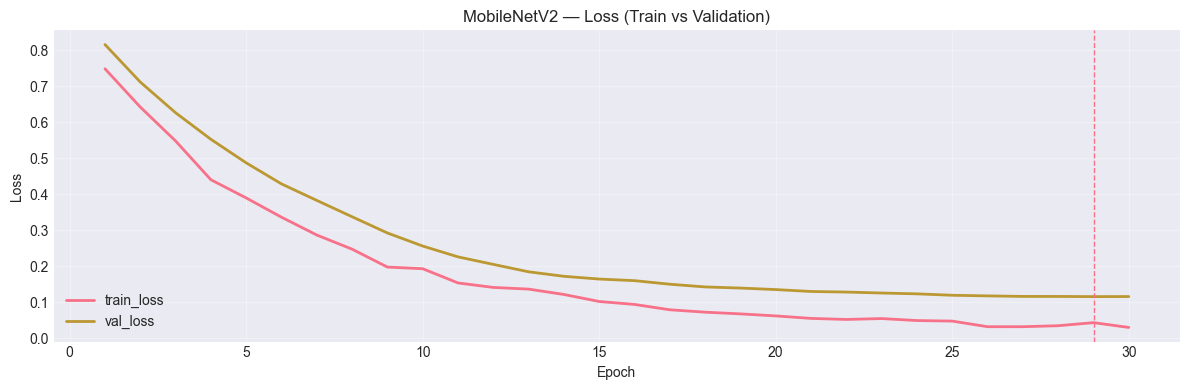

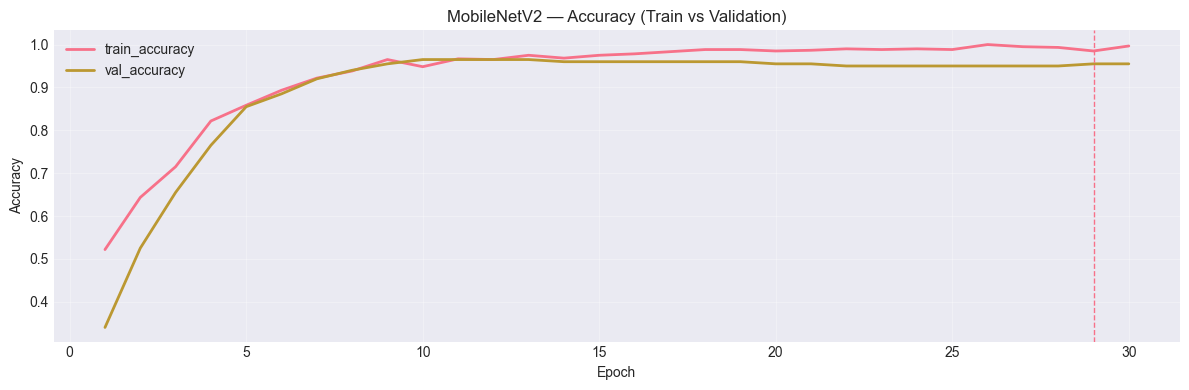

In [29]:
best_model_name = results_df.loc[results_df["F1-Score"].idxmax(), "Model"]

history_map = {
    "CustomCNN": history_custom,
    "LeNet5": history_lenet5,
    "MobileNetV2": history_mobilenet
}

best_history = history_map[best_model_name]

train_loss = np.array(best_history.history["loss"])
val_loss   = np.array(best_history.history["val_loss"])
train_acc  = np.array(best_history.history["accuracy"])
val_acc    = np.array(best_history.history["val_accuracy"])

epochs = np.arange(1, len(train_loss) + 1)

best_epoch_idx = int(np.argmin(val_loss))
best_epoch = best_epoch_idx + 1

gap_acc  = float(train_acc[best_epoch_idx] - val_acc[best_epoch_idx])
gap_loss = float(val_loss[best_epoch_idx] - train_loss[best_epoch_idx])

print(f"\nBest epoch: {best_epoch}")
print(f"Accuracy:\n\tTrain accuracy: {train_acc[best_epoch_idx]:.4f}\n\tVal accuracy: {val_acc[best_epoch_idx]:.4f}\n\tGap: {gap_acc:.4f}")
print(f"Loss:\n\tTrain loss: {train_loss[best_epoch_idx]:.4f}\n\tVal loss: {val_loss[best_epoch_idx]:.4f}\n\tGap: {gap_loss:.4f}")

if gap_acc > 0.08 and gap_loss > 0.10:
    res = "Probable overfitting"
elif val_acc[best_epoch_idx] < 0.75 and train_acc[best_epoch_idx] < 0.80:
    res = "Probable underfitting"
else:
    res = "No significant signs of overfitting or underfitting"

print("\n", res)

plt.figure(figsize=(12, 4))
plt.plot(epochs, train_loss, label="train_loss", linewidth=2)
plt.plot(epochs, val_loss, label="val_loss", linewidth=2)
plt.axvline(best_epoch, linestyle="--", linewidth=1)
plt.title(f"{best_model_name} — Loss (Train vs Validation)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, train_acc, label="train_accuracy", linewidth=2)
plt.plot(epochs, val_acc, label="val_accuracy", linewidth=2)
plt.axvline(best_epoch, linestyle="--", linewidth=1)
plt.title(f"{best_model_name} — Accuracy (Train vs Validation)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Zaver


Vlastná CNN architektúra dosiahla na testovacej množine presnosť 0,925 a hodnotu F1-score 0,926. Model vykazoval vysokú hodnotu recall 0,969, avšak nižšiu precision 0,887, čo naznačuje vyšší počet falošne pozitívnych klasifikácií. Confusion matrix potvrdzuje, že model má tendenciu chybne klasifikovať niektoré vzorky triedy without mask. Vlastná CNN tak slúžila ako základný referenčný model, ktorý dokázal zachytiť základné vizuálne rozdiely.

Architektúra LeNet-5 dosiahla mierne nižšiu presnosť 0,910 a F1-score 0,909, pričom hodnoty precision 0,891 a recall 0,928 sú vyváženejšie než pri vlastnej CNN. Počet nesprávnych klasifikácií bol nižší a rovnomernejšie rozdelený medzi obe triedy, čo naznačuje stabilnejšie správanie modelu

Najlepšie výsledky dosiahol model MobileNetV2, ktorý na testovacej množine dosiahol presnosť 0,980, precision 0,960, recall 1,000 a F1-score 0,978. Confusion matrix potvrdzuje minimálny počet nesprávnych klasifikácií v oboch triedach. Tieto výsledky poukazujú na veľmi dobrú generalizačnú schopnosť modelu. Na základe získaných výsledkov možno konštatovať, že zvolený prístup bol vhodný pre daný dataset.

Porovnanie viacerých CNN architektúr ukázalo, že modely s vyššou architektonickou zložitosťou a využitím transfer learningu dosahujú lepšie klasifikačné výsledky než jednoduchšie CNN modely. Model MobileNetV2 bol preto zvolený ako najlepší model a predstavuje najvhodnejšie riešenie pre ďalšie použitie